In [1]:
import pandas as pd
print(pd.__version__)

3.0.1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries ready!")

All libraries ready!


In [3]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
matches.head()

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
print("Seasons covered:", matches['season'].min(), "to", matches['season'].max())
print("Total teams:", matches['team1'].nunique())
print("Total venues:", matches['venue'].nunique())
print("\nMissing values in matches:")
print(matches.isnull().sum())

Seasons covered: 2007/08 to 2024
Total teams: 19
Total venues: 58

Missing values in matches:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_8048\1806805652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette='viridis')


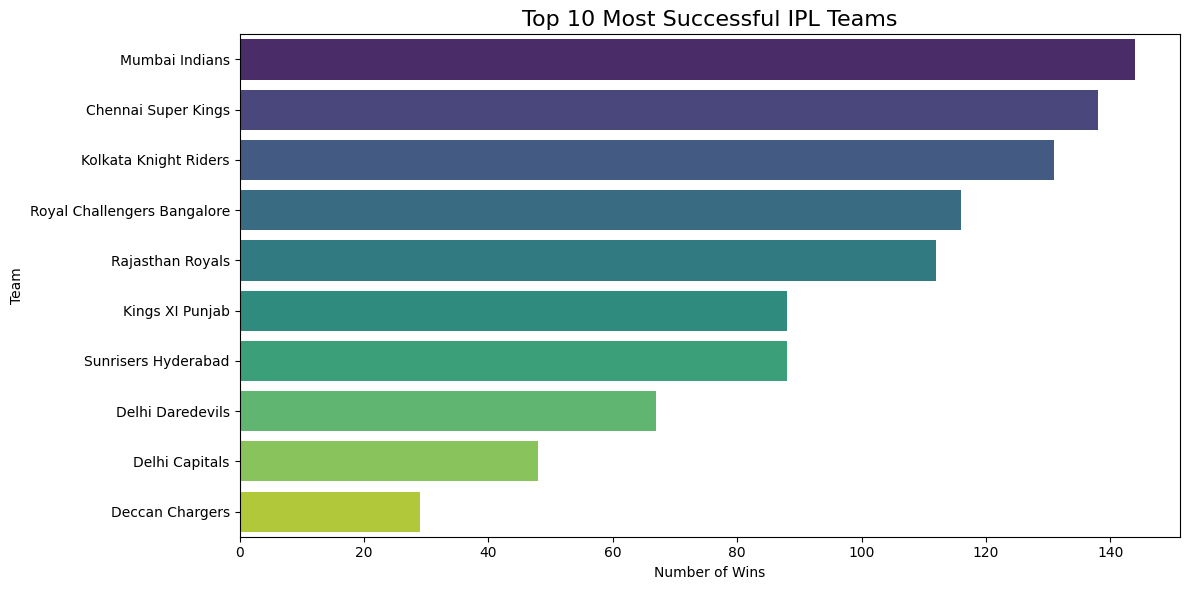

Most successful team: Mumbai Indians with 144 wins


In [5]:
team_wins = matches['winner'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=team_wins.values, y=team_wins.index, palette='viridis')
plt.title('Top 10 Most Successful IPL Teams', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('team_wins.png', dpi=150)
plt.show()
print("Most successful team:", team_wins.index[0], "with", team_wins.values[0], "wins")

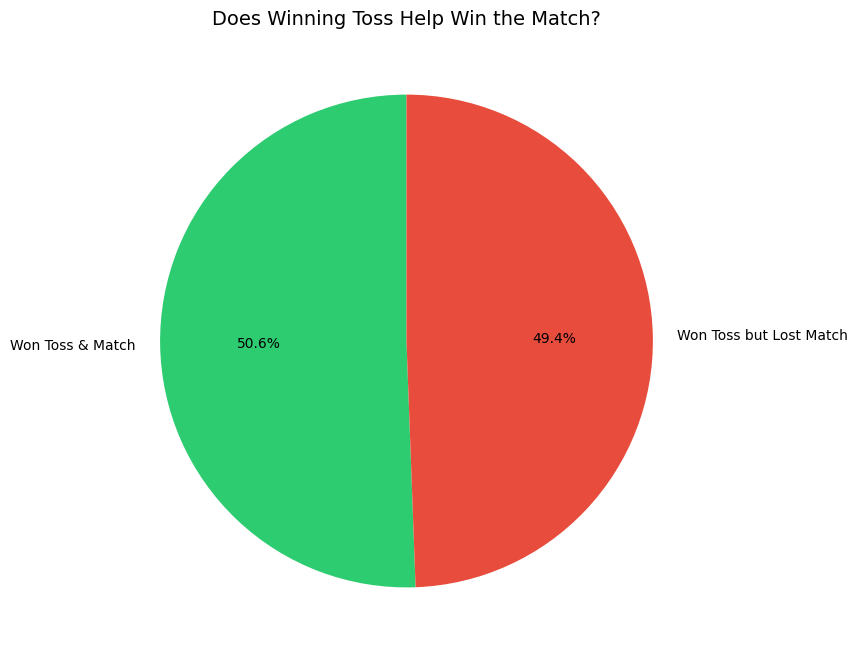

50.59% of toss winners also won the match


In [6]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]
percentage = round(len(toss_win_match_win) / len(matches) * 100, 2)

labels = ['Won Toss & Match', 'Won Toss but Lost Match']
sizes = [percentage, 100 - percentage]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Does Winning Toss Help Win the Match?', fontsize=14)
plt.savefig('toss_analysis.png', dpi=150)
plt.show()
print(f"{percentage}% of toss winners also won the match")

C:\Users\USER\AppData\Local\Temp\ipykernel_8048\1615200825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='rocket')


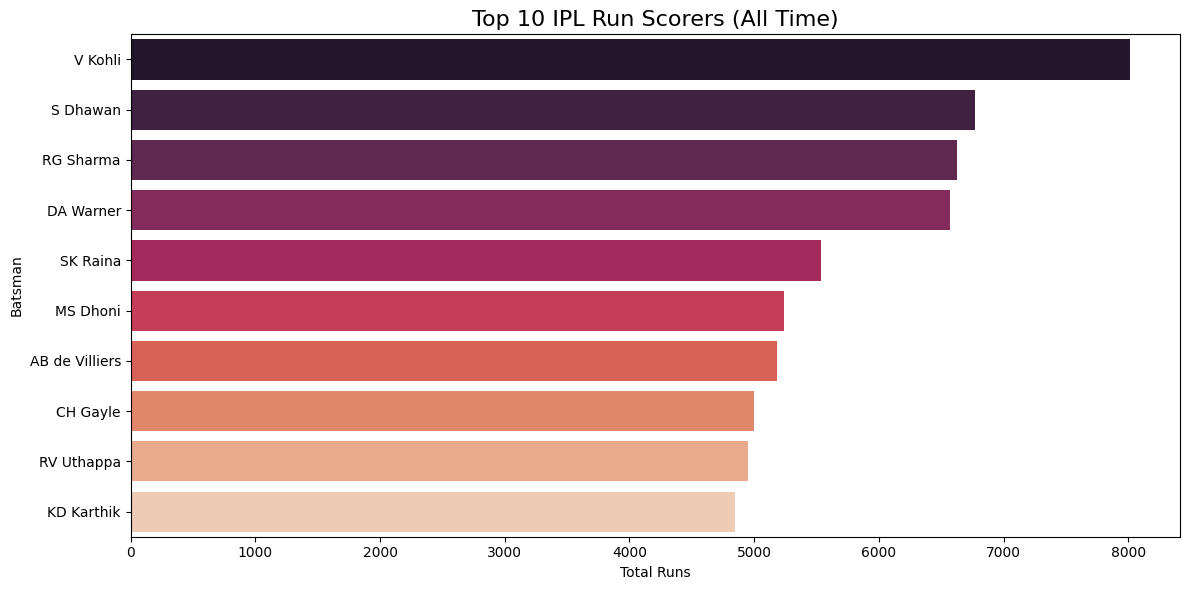

Top run scorer: V Kohli with 8014 runs


In [7]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='rocket')
plt.title('Top 10 IPL Run Scorers (All Time)', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('top_batsmen.png', dpi=150)
plt.show()
print("Top run scorer:", top_batsmen.index[0], "with", top_batsmen.values[0], "runs")

C:\Users\USER\AppData\Local\Temp\ipykernel_8048\3927757755.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='magma')


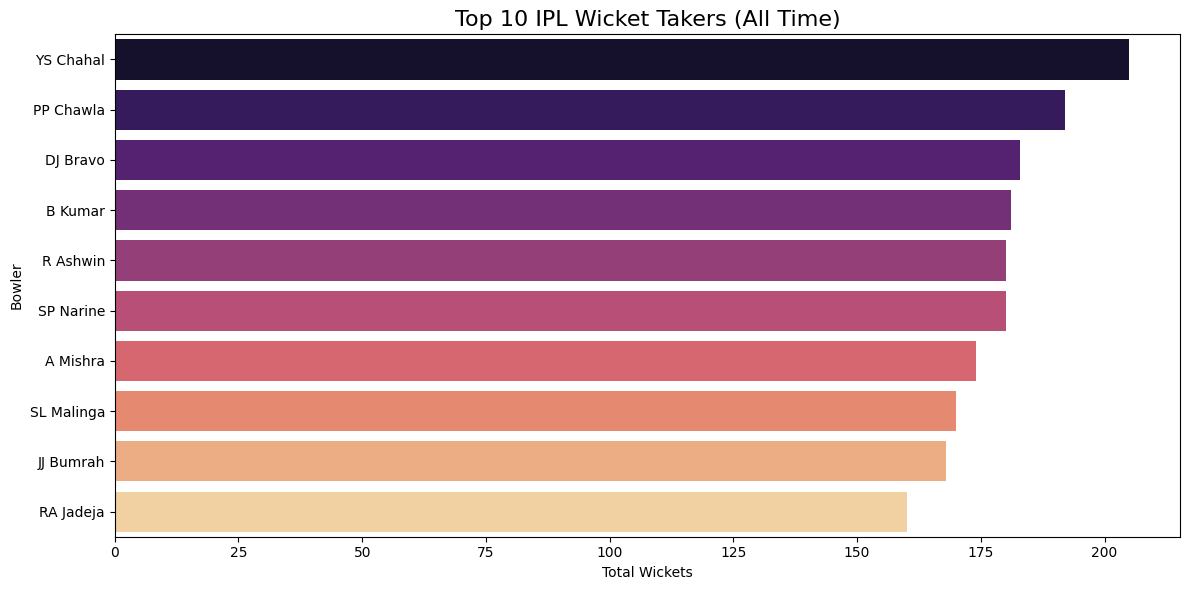

Top wicket taker: YS Chahal with 205 wickets


In [8]:
wickets = deliveries[deliveries['dismissal_kind'].notna()]
wickets = wickets[~wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='magma')
plt.title('Top 10 IPL Wicket Takers (All Time)', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi=150)
plt.show()
print("Top wicket taker:", top_bowlers.index[0], "with", top_bowlers.values[0], "wickets")

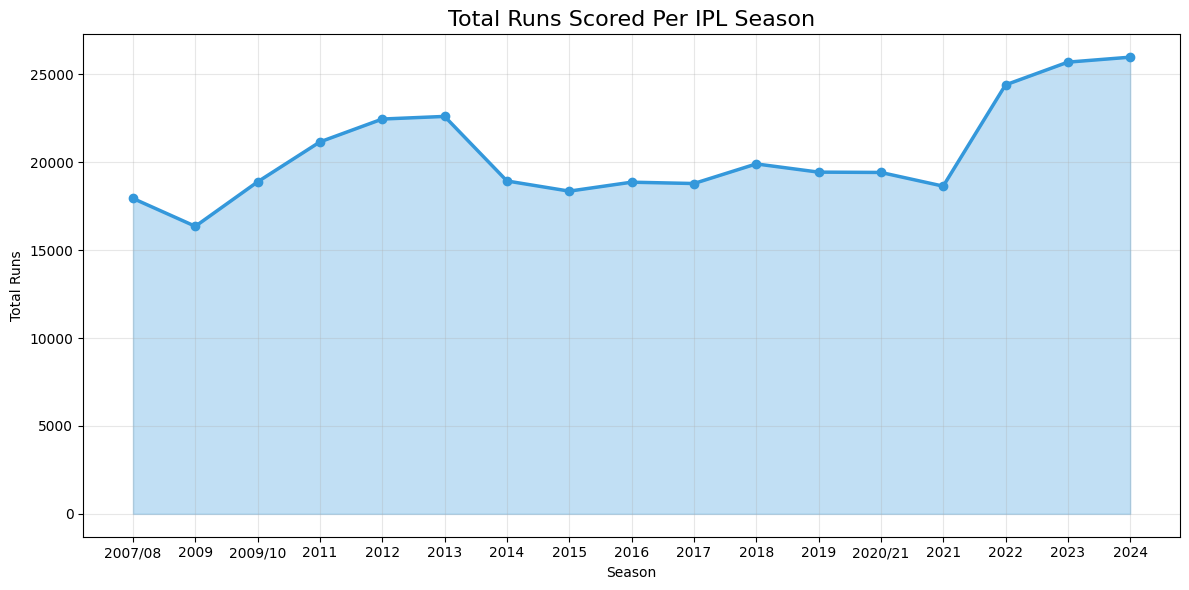

In [9]:
season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_avg = season_runs.groupby('season')['total_runs'].sum()

plt.figure(figsize=(12, 6))
plt.plot(season_avg.index, season_avg.values, marker='o', linewidth=2.5, color='#3498db')
plt.fill_between(season_avg.index, season_avg.values, alpha=0.3, color='#3498db')
plt.title('Total Runs Scored Per IPL Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('season_runs.png', dpi=150)
plt.show()

In [11]:
print("=" * 50)
print("KEY INSIGHTS FROM IPL DATA ANALYSIS")
print("=" * 50)
print(f"✅ Total matches analyzed: {len(matches)}")
print(f"✅ Most successful team: {team_wins.index[0]} ({team_wins.values[0]} wins)")
print(f"✅ Toss advantage: {percentage}% toss winners won the match")
print(f"✅ Top run scorer: {top_batsmen.index[0]} ({top_batsmen.values[0]} runs)")
print(f"✅ Top wicket taker: {top_bowlers.index[0]} ({top_bowlers.values[0]} wickets)")
print("=" * 50)
print("\nProject Complete! Ready for GitHub")

KEY INSIGHTS FROM IPL DATA ANALYSIS
✅ Total matches analyzed: 1095
✅ Most successful team: Mumbai Indians (144 wins)
✅ Toss advantage: 50.59% toss winners won the match
✅ Top run scorer: V Kohli (8014 runs)
✅ Top wicket taker: YS Chahal (205 wickets)

Project Complete! Ready for GitHub
